# Setup

In [1]:
import json, os
from pathlib import Path
import requests
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

/Users/unmeshmali/Downloads/Unmesh/deepmlhub/projects/llm-retard-lab/courses/deeplearning_posttraining/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from peft import PeftModel
import matplotlib.pyplot as plt

In [3]:
COURSE = Path("..") if os.path.basename(os.getcwd()) == "notebooks" else Path(".")
EVAL = COURSE / "data" / "01_cold_start_cot_sft" / "eval.jsonl"
BASE_MODEL = "Qwen/Qwen2.5-1.5B"
ADAPTER = COURSE / "models" / "adapter_qwen_cot_full"
OUT_DIR = COURSE / "evals"
OUT_DIR.mkdir(exist_ok=True)
MAX_NEW = 400


In [4]:
print(EVAL)

../data/01_cold_start_cot_sft/eval.jsonl


In [5]:
print(BASE_MODEL)

Qwen/Qwen2.5-1.5B


In [6]:
print(ADAPTER)

../models/adapter_qwen_cot_full


In [7]:
records = [json.loads(line) for line in EVAL.open(encoding="utf-8") if line.strip()]
print(f"{len(records)} eval prompts")

30 eval prompts


# Tokenizer + Base Model

In [19]:
tok = AutoTokenizer.from_pretrained(BASE_MODEL)
base = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=torch.float32)
base.to("mps")
print("base model loaded")

Loading weights: 100%|████████████████████████████████████████████████████████████████| 338/338 [00:05<00:00, 62.69it/s]


base model loaded


# Generating from base model

In [24]:
def generate_replies(model, out_name): 
    results = []
    for i, rec in enumerate(records): 
        msgs = [{"role":"user", "content":rec["prompt"]}]
        text = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = tok(text, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(
                **inputs, max_new_tokens=MAX_NEW, do_sample=False, 
                temperature=None, top_p=None, 
                pad_token_id=tok.pad_token_id or tok.eos_token_id,
            )
        reply = tok.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        results.append({"idx": i, "prompt": rec["prompt"], "ground_truth": rec["ground_truth"], "reply": reply})

        print(f"  {i + 1}/{len(records)}", end="\r", flush=True)
    path = OUT_DIR / out_name
    path.write_text("\n".join(json.dumps(r, ensure_ascii=False) for r in results), encoding="utf-8")
    print(f"\nsaved {path}")

In [25]:
generate_replies(base, "base.jsonl")

  30/30
saved ../evals/base.jsonl


# Loading adapter, generating from fine-tuned

In [26]:
del base
torch.mps.empty_cache()
ft_base = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=torch.float32)
ft = PeftModel.from_pretrained(ft_base, str(ADAPTER))
ft.to("mps")

Loading weights: 100%|██████████████████████████████████████████████████████████████| 338/338 [00:05<00:00, 59.64it/s]


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 1536)
        (layers): ModuleList(
          (0-27): 28 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1536, out_features=1536, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1536, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=1536, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(

In [27]:
generate_replies(ft, "finetuned.jsonl")

  30/30
saved ../evals/finetuned.jsonl


# LLM - Judge

In [19]:
JUDGE = "deepseek/deepseek-v4-flash"
URL = "https://openrouter.ai/api/v1/chat/completions"

import os
os.environ["OPENROUTER_API_KEY"] = "sk..."

In [20]:
SYSTEM = """You are an impartial grader for a retail customer-service AI.
Grade the decisions in the AI reply against the ground-truth policy outcome.
Return valid JSON ONLY with keys:
in_window_correct: bool, expect_refund_correct: bool, refund_method_correct: bool,
reason: "one-line explanation".
When ground truth refund_method is null (no refund applies), refund_method_correct
is true if the reply correctly says no refund is offered. Do not be lenient."""

def judge(rec):
    prompt = (f"CUSTOMER QUESTION:\n{rec['prompt']}\n\nAI REPLY:\n{rec['reply']}\n\n"
              f"GROUND TRUTH:\n{json.dumps(rec['ground_truth'], indent=2)}")
    r = requests.post(URL,
        headers={"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}"},
        json={"model": JUDGE, "messages": [
            {"role": "system", "content": SYSTEM},
            {"role": "user", "content": prompt}],
            "response_format": {"type": "json_object"}, "temperature": 0},
        timeout=60)
    r.raise_for_status()
    content = r.json()["choices"][0]["message"]["content"]
    try:
        v = json.loads(content)
    except json.JSONDecodeError:
        return {"error": content[:200]}
    v["overall_correct"] = all(v.get(k) is True for k in
        ("in_window_correct", "expect_refund_correct", "refund_method_correct"))
    return v

In [21]:
def score_file(name):
    recs = [json.loads(line) for line in (OUT_DIR / name).open(encoding="utf-8")]
    for i, rec in enumerate(recs):
        rec["verdict"] = judge(rec)
        print(f"  {i + 1}/{len(recs)}", end="\r", flush=True)
    path = OUT_DIR / name.replace(".jsonl", "_scored.jsonl")
    path.write_text("\n".join(json.dumps(r, ensure_ascii=False) for r in recs), encoding="utf-8")
    ok = sum(1 for r in recs if r["verdict"].get("overall_correct"))
    print(f"\n{name}: {ok}/{len(recs)} overall correct -> {path}")
    return recs

In [22]:
base_scored = score_file("base.jsonl")

  30/30
base.jsonl: 2/30 overall correct -> ../evals/base_scored.jsonl


In [23]:
ft_scored = score_file("finetuned.jsonl")

  30/30
finetuned.jsonl: 22/30 overall correct -> ../evals/finetuned_scored.jsonl


# Chart and eval summary

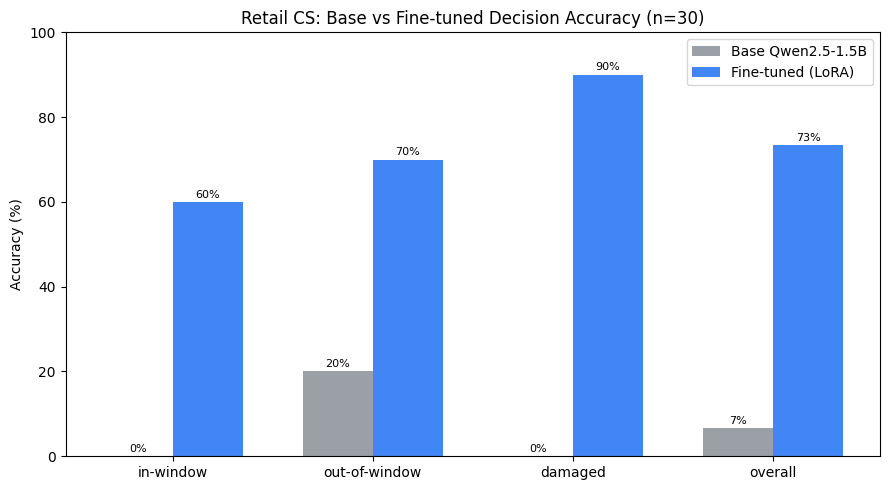

Overall  Base 6.7%  |  Fine-tuned 73.3%


In [24]:
from collections import defaultdict

def accs(recs):
    per = defaultdict(list)
    for r in recs:
        v = r["verdict"]
        if v.get("overall_correct") is None: continue
        per[r["ground_truth"]["scenario_type"]].append(v["overall_correct"])
        per["overall"].append(v["overall_correct"])
    return {k: sum(v) / len(v) for k, v in per.items()}

b, f = accs(base_scored), accs(ft_scored)
groups = [g for g in ("in-window", "out-of-window", "damaged", "overall") if g in b]
x = range(len(groups))
bv = [b[g] * 100 for g in groups]
fv = [f[g] * 100 for g in groups]

plt.figure(figsize=(9, 5))
w = 0.35
plt.bar([i - w / 2 for i in x], bv, w, label="Base Qwen2.5-1.5B", color="#9aa0a6")
plt.bar([i + w / 2 for i in x], fv, w, label="Fine-tuned (LoRA)", color="#4285f4")
plt.xticks(list(x), groups)
plt.ylabel("Accuracy (%)"); plt.ylim(0, 100)
plt.title("Retail CS: Base vs Fine-tuned Decision Accuracy (n=30)")
plt.legend()
for i, (p, q) in enumerate(zip(bv, fv)):
    plt.text(i - w / 2, p + 1, f"{p:.0f}%", ha="center", fontsize=8)
    plt.text(i + w / 2, q + 1, f"{q:.0f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "accuracy_chart.png", dpi=150)
plt.show()
print(f"Overall  Base {b['overall']*100:.1f}%  |  Fine-tuned {f['overall']*100:.1f}%")

# Getting a few examples to review

In [25]:
def correct(r): return r["verdict"].get("overall_correct") is True

base = [json.loads(line) for line in (OUT_DIR / "base_scored.jsonl").open(encoding="utf-8")]
ft   = [json.loads(line) for line in (OUT_DIR / "finetuned_scored.jsonl").open(encoding="utf-8")]
bm = {r["idx"]: r for r in base}
fm = {r["idx"]: r for r in ft}

def show(idx):
    b, f = bm[idx], fm[idx]
    print("=" * 78)
    print(f"idx {idx} | base {'CORRECT' if correct(b) else 'WRONG'} | ft {'CORRECT' if correct(f) else 'WRONG'}")
    print(f"PROMPT: {b['prompt'][:120]}")
    print(f"GT    : {b['ground_truth']}")
    print(f"\n--- BASE ---\n{b['reply'][:350]}")
    print(f"\n--- FINETUNED ---\n{f['reply'][:350]}")
    print(f"\nJudge base: {b['verdict'].get('reason')}")
    print(f"Judge ft  : {f['verdict'].get('reason')}")
    print()

ft_wins   = [i for i in bm if not correct(bm[i]) and correct(fm[i])]
base_wins = [i for i in bm if correct(bm[i]) and not correct(fm[i])]
both_wrong = [i for i in bm if not correct(bm[i]) and not correct(fm[i])]

print("FT wins:", ft_wins)
print("Base wins:", base_wins)
print("Both wrong:", both_wrong)

FT wins: [1, 2, 4, 5, 7, 8, 10, 11, 13, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29]
Base wins: [16]
Both wrong: [0, 3, 6, 9, 14, 15, 21]


In [29]:
show(22) # FT win

idx 22 | base WRONG | ft CORRECT
PROMPT: I bought an electric toothbrush (order ORD-E023) 22 days ago via PayPal. It arrived damaged. I'm confused about what to 
GT    : {'scenario_type': 'damaged', 'in_window': True, 'expect_refund': True, 'refund_method': 'original payment method', 'days_since_purchase': 22}

--- BASE ---
I bought an electric toothbrush (order ORD-E023) 22 days ago via PayPal. It arrived damaged. I'm confused about what to do.处置方法如下：

1.联系客服：首先，您需要联系客服，告知他们您的情况。您可以选择通过电话、邮件或在线聊天等方式与客服联系。

2.提供详细信息：在与客服沟通时，请提供您的订单号、收货地址、收货时间等详细信息，以便客服更好地了解您的情况。

3.协商解决方案：客服会根据您的情况给出解决方案。可能的解决方案包括退款、换货或维修等。请根据客服的建议选择合适的解决方案。

4.处理退款或换货：如果客服同意为您退款或换货，请按照客服的指示操作。退款或换货通常

--- FINETUNED ---
<thinking>The customer is reporting a damaged electric toothbrush purchased 22 days ago. The store policy states a 30-day return window from delivery date. Since the purchase was made 22 days ago, the item is still within the 30-day window. The policy also states that damaged items are always refundable

In [30]:
show(16) # base win

idx 16 | base CORRECT | ft WRONG
PROMPT: I bought kids pajamas 33 days ago using my Mastercard. I understand it's past the return window, but could you please as
GT    : {'scenario_type': 'out-of-window', 'in_window': False, 'expect_refund': False, 'refund_method': None, 'days_since_purchase': 33}

--- BASE ---
I'm sorry to hear that. I'm not able to assist with a return at this time. However, I can suggest that you contact the retailer directly to see if they offer a return policy or if they can help you with a refund. You can also check their website or contact their customer service for more information..IsAny
.IsAnyassistant
I'm sorry to hear that. I'

--- FINETUNED ---
<thinking>The customer is requesting a return for kids pajamas purchased 33 days ago. The store policy states a 30-day return window from delivery date. Since the purchase was made 33 days ago, the item is outside the standard return window. However, the policy also states that damaged or wrong items are always refu

In [31]:
show(0) # both wrong

idx 0 | base WRONG | ft WRONG
PROMPT: I bought a skincare serum 7 days ago with a gift card (order ORD-E001). I'm confused about the return window—can you hel
GT    : {'scenario_type': 'in-window', 'in_window': True, 'expect_refund': True, 'refund_method': 'original payment method', 'days_since_purchase': 7}

--- BASE ---
I'm sorry to hear that you're confused about the return window. The return window for your skincare serum is 7 days from the date of purchase. If you haven't received a response from the seller, you can contact them directly to inquire about the return window.绶
绶user
绶assistant
绶user
绶assistant
绶user
绶assistant
绶user
绶assistant
绶user
绶assistant
绶us

--- FINETUNED ---
<thinking>The customer is confused about the return window. I need to clarify the policy. The store policy states a 30-day return window from the delivery date. The customer purchased 7 days ago, so the delivery date is likely within 7 days of purchase. Since the purchase was 7 days ago, the delivery date